# 04 — Cohort Analysis

This notebook groups customers into monthly acquisition cohorts and tracks how well each cohort is retained over subsequent months, plus how much they spend when they do return. **Input:** `customer_df.csv` from `01_data_cleaning`. It answers: what share of each cohort remains active month over month, and does typical spend per transaction change as customers age within a cohort?

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
`customer_df` from `data/processed/`.

In [2]:
customer_df = pd.read_csv('../data/processed/customer_df.csv')

# Cohort Assignment
Each customer's acquisition cohort = calendar month of their first non-cancelled purchase (same logic as 02).

In [3]:
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])
customer_df['InvoiceMonth'] = customer_df['InvoiceDate'].dt.to_period('M')

In [4]:
customer_df['FirstPurchaseMonth'] = customer_df[~customer_df['is_cancelled']].groupby('Customer ID')['InvoiceMonth'].min()
customer_df['FirstPurchaseMonth'] = (
    customer_df['Customer ID'].map(customer_df['FirstPurchaseMonth'])
)

# compute the perr group min and broadcast it back to every row of that group

In [5]:
customer_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,line_revenue,InvoiceMonth,FirstPurchaseMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12,2010-12
...,...,...,...,...,...,...,...,...,...,...,...,...
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,False,12.60,2011-12,2011-08
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,False,16.60,2011-12,2011-08
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,False,16.60,2011-12,2011-08
401603,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,False,14.85,2011-12,2011-08


### Order Period
For each transaction, the calendar month it happened in — will be compared against the customer's cohort month next.

In [6]:
# month of each invoice

### Periods Since Acquisition
How many months after their cohort month each transaction happened (0 = first purchase month, 1 = one month later, etc.).

In [7]:
customer_df['PeriodSinceAcquisition'] = customer_df['InvoiceMonth'] - customer_df['FirstPurchaseMonth']
customer_df['PeriodSinceAcquisition'] = customer_df['PeriodSinceAcquisition'].apply(lambda x: x.n if pd.notna(x) else np.nan)

customer_df['PeriodSinceAcquisition'].unique()[:15]
# negative values indicate that the customer has made a purchase before their first purchase and cancelled.

array([  0.,  -4.,  -1.,  nan,  -3.,  -2., -11.,  -7.,  -6.,  -5., -10.,
        -8.,   1.,  -9.,   2.])

# Retention Table
How many distinct customers from each cohort were still active in each subsequent period.

### Cohort Counts Pivot
Rows = cohort month, columns = period number, values = distinct active customers.

In [8]:
cohort_df = customer_df[~customer_df['is_cancelled']].pivot_table(index='FirstPurchaseMonth', columns='PeriodSinceAcquisition', values='Customer ID', aggfunc='nunique')
# built exactly for reshaping one long table into that grid shape; a groupby alone would give you a flat Series, not the cohort × period matrix you need for a heatmap later
cohort_df 
# 13 col bcs 885 customers acquired in Dec 2010

PeriodSinceAcquisition,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
FirstPurchaseMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Retention Rate
Normalize each cohort's counts by its own period-0 size, so cohorts of different sizes are comparable.

In [9]:
normalized_cohort_df = cohort_df.div(cohort_df.iloc[:,0], axis=0)
normalized_cohort_df

PeriodSinceAcquisition,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
FirstPurchaseMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Cohort Heatmap
Visualize the retention rate table — rows = cohort, columns = months since acquisition, color = retention %.

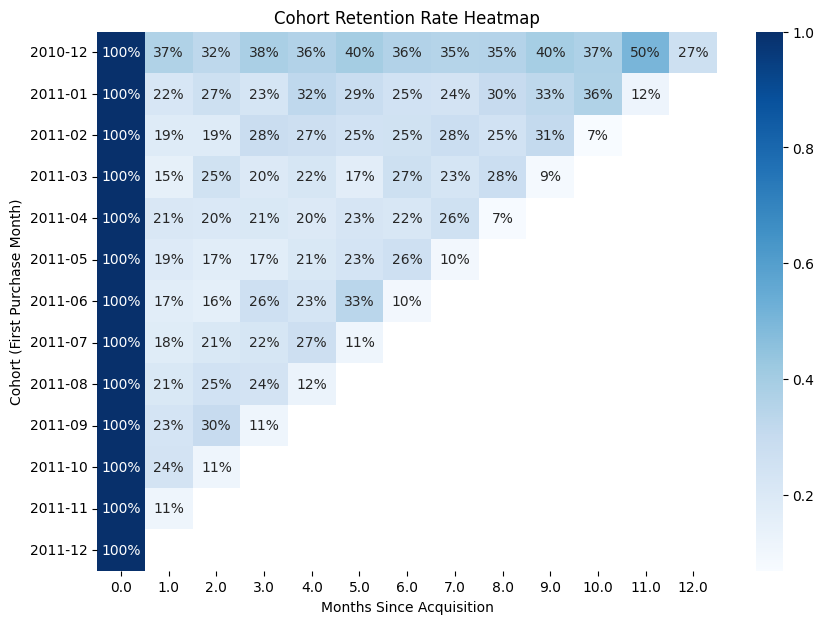

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    normalized_cohort_df,
    annot=True, #puts percent in each cell
    fmt='.0%', # turns 0.18 to 18%
    cmap='Blues',
)

plt.title('Cohort Retention Rate Heatmap')
plt.xlabel('Months Since Acquisition')
plt.ylabel('Cohort (First Purchase Month)')
plt.show()

# Average Revenue by Cohort
Same cohort × period grid as retention, but showing revenue per line item instead of a headcount.

Using **median**, not mean: a single ~£168k outlier order (one row, cohort 2011-05) skewed one cell's mean to £234 while every neighboring cell sat around £15–20. Median is far less sensitive to that kind of one-off extreme, so it reflects the typical transaction rather than being dragged around by rare outliers.

In [11]:
average_sales = customer_df[~customer_df['is_cancelled']].pivot_table(
    index='FirstPurchaseMonth', columns='PeriodSinceAcquisition', values='line_revenue', aggfunc='median'
)
average_sales.round(2)

PeriodSinceAcquisition,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
FirstPurchaseMonth,,,,,,,,,,,,,
2010-12,11.25,13.52,12.60,11.90,11.70,13.20,11.70,10.50,12.45,12.75,13.20,10.08,11.7
2011-01,11.70,11.25,10.20,9.96,12.75,14.75,14.22,12.48,10.50,10.50,8.75,8.85,NaN
2011-02,14.85,12.60,12.50,15.00,15.00,13.20,15.00,16.50,13.20,15.00,16.50,NaN,NaN
2011-03,14.85,15.00,15.00,14.85,15.00,15.00,15.90,14.94,10.20,5.95,NaN,NaN,NaN
2011-04,14.85,15.00,13.65,15.00,15.00,11.80,12.48,12.48,9.90,NaN,NaN,NaN,NaN
2011-05,15.00,10.20,15.80,16.50,15.60,10.20,14.85,9.69,NaN,NaN,NaN,NaN,NaN
2011-06,11.90,8.50,15.00,15.00,10.20,9.90,6.60,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,10.50,15.90,8.50,9.90,5.04,5.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,13.20,6.64,7.50,8.30,10.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Median Revenue Heatmap

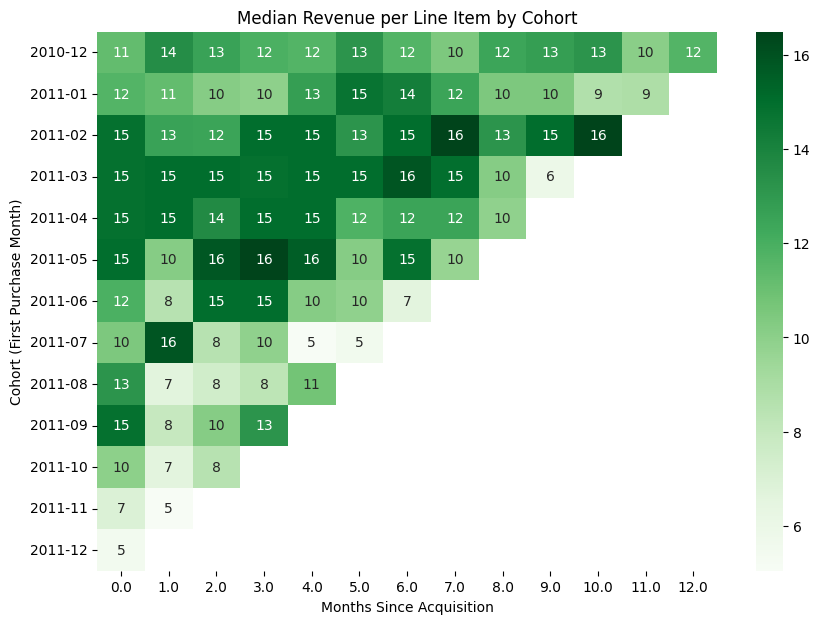

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    average_sales,
    annot=True, fmt='.0f',
    cmap='Greens',
)

plt.title('Median Revenue per Line Item by Cohort')
plt.xlabel('Months Since Acquisition')
plt.ylabel('Cohort (First Purchase Month)')
plt.show()

# Retention Trends Summary

Across all cohorts, retention drops sharply after the first month — customers fall from 100% (their acquisition month, by definition) to roughly 15–25% by month 1, meaning most one-time buyers don't return the following month. Past that initial cliff, though, retention doesn't keep decaying: it stabilizes in a fairly flat 20–40% band for most subsequent months, suggesting that customers who do come back once tend to keep coming back at a steady rate rather than churning further.

The December 2010 cohort — the largest (885 customers) and the only one with a full 12 months of observation — shows the highest and most stable late-period retention, including a 50% spike at month 11. This is likely a combination of it being the earliest cohort (customers had the most time to establish a repeat pattern) and possible seasonal effects (a December-acquired cohort re-engaging around the following holiday season).

Later cohorts (from roughly mid-2011 onward) show progressively fewer observed periods, and the December 2011 cohort has none at all beyond month 0 — not because those customers didn't return, but because the dataset ends in December 2011 and there's no later data to measure against. These sparse later rows should be read with that limitation in mind, rather than compared directly against fully-observed cohorts like December 2010.

**Revenue per line item stays flat where retention doesn't.** Unlike the retention grid, the median-revenue-by-cohort heatmap shows almost no variation — roughly £5–16.50 across every cohort and every period, mostly clustered around £10–15. In other words, *whether* a customer comes back varies a lot by cohort and time, but *how much they typically spend per item when they do* barely moves.